<a href="https://colab.research.google.com/github/varsha-lab2028/NeuroFlow/blob/main/NeuroFlowML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting data from the Zip file

In [ ]:
#mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

In [ ]:
#zip path name
ZIP_PATH = '/content/drive/MyDrive/NEUROFLOW ML/onhw-chars_2021-06-30.zip'
EXTRACT_TO = '/content/onhw'

In [ ]:
#extracting the data from the zip file
print('Extracting... this takes 2-3 minutes')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)
print('Done.')

Extracting... this takes 2-3 minutes
Done.


In [ ]:
#see what the folder structure looks like
for root, dirs, files in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            print(f'  {indent}({len(files)} files)')

onhw/
  onhw-chars_2021-06-30/
    onhw2_both_indep_4/
      (4 files)
    onhw2_upper_indep_0/
      (4 files)
    onhw2_lower_dep_2/
      (4 files)
    onhw2_upper_dep_4/
      (4 files)
    onhw2_both_dep_4/
      (4 files)
    onhw2_both_indep_3/
      (4 files)
    onhw2_both_indep_1/
      (4 files)
    onhw2_upper_indep_4/
      (4 files)
    onhw2_both_dep_1/
      (4 files)
    onhw2_lower_indep_1/
      (4 files)
    onhw2_upper_indep_1/
      (4 files)
    onhw2_lower_dep_0/
      (4 files)
    onhw2_upper_dep_0/
      (4 files)
    onhw2_upper_indep_3/
      (4 files)
    onhw2_lower_dep_3/
      (4 files)
    onhw2_both_dep_0/
      (4 files)
    onhw2_lower_indep_0/
      (4 files)
    onhw2_both_indep_0/
      (4 files)
    onhw2_lower_dep_4/
      (4 files)
    onhw2_upper_dep_2/
      (4 files)
    onhw2_lower_indep_3/
      (4 files)
    onhw2_both_indep_2/
      (4 files)
    onhw2_both_dep_3/
      (4 files)
    onhw2_both_dep_2/
      (4 files)
    onhw2_upper_dep

Inspecting the structure of the data

In [ ]:
import os, pandas as pd
base = '/content/onhw/onhw-chars_2021-06-30'

In [ ]:
# See the 4 files inside one folder
sample_folder = os.path.join(base, 'onhw2_lower_indep_0')
print("Files in sample folder:")
for f in os.listdir(sample_folder):
    print(' ', f)
print()

Files in sample folder:
  y_train.npy
  X_test.npy
  X_train.npy
  y_test.npy



In [ ]:
# Open each file and show its shape + first 3 rows
for fname in os.listdir(sample_folder):
    fpath = os.path.join(sample_folder, fname)
    try:
        df = pd.read_csv(fpath, nrows=3)
        print(f"--- {fname} ---")
        print(f"Shape: {df.shape}")
        print(df.head(3))
        print()
    except Exception as e:
        print(f"{fname}: {e}")

y_train.npy: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte
X_test.npy: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte
X_train.npy: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte
y_test.npy: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte


Load and Inspect Arrays

In [ ]:
import numpy as np
base = '/content/onhw/onhw-chars_2021-06-30'
folder = base + '/onhw2_lower_indep_0'

In [ ]:
X_train = np.load(folder + '/X_train.npy', allow_pickle=True)
y_train = np.load(folder + '/y_train.npy', allow_pickle=True)
X_test  = np.load(folder + '/X_test.npy',  allow_pickle=True)
y_test  = np.load(folder + '/y_test.npy',  allow_pickle=True)

In [ ]:
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape: ', X_test.shape)
print('y_test shape: ', y_test.shape)
print()
print('X_train dtype:', X_train.dtype)
print('y_train dtype:', y_train.dtype)
print()
print('Sample X_train[0] shape:', np.array(X_train[0]).shape if hasattr(X_train[0], '__len__') else X_train[0])
print('First 10 y_train labels:', y_train[:10])
print('Unique labels:', np.unique(y_train))
print('Total unique labels:', len(np.unique(y_train)))

X_train shape: (11647,)
y_train shape: (11647,)
X_test shape:  (3978,)
y_test shape:  (3978,)

X_train dtype: object
y_train dtype: <U1

Sample X_train[0] shape: (32, 13)
First 10 y_train labels: ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j']
Unique labels: ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']
Total unique labels: 26


Check column names

In [ ]:
import os
# Find and read the README or any metadata file
base = '/content/onhw/onhw-chars_2021-06-30'
for f in os.listdir(base):
    print(f)

onhw2_both_indep_4
onhw2_upper_indep_0
onhw2_lower_dep_2
onhw2_upper_dep_4
onhw2_both_dep_4
onhw2_both_indep_3
onhw2_both_indep_1
onhw2_upper_indep_4
onhw2_both_dep_1
onhw2_lower_indep_1
onhw2_upper_indep_1
onhw2_lower_dep_0
onhw2_upper_dep_0
onhw2_upper_indep_3
onhw2_lower_dep_3
readme.txt
onhw2_both_dep_0
onhw2_lower_indep_0
onhw2_both_indep_0
onhw2_lower_dep_4
onhw2_upper_dep_2
onhw2_lower_indep_3
onhw2_both_indep_2
onhw2_both_dep_3
onhw2_both_dep_2
onhw2_upper_dep_3
onhw2_lower_dep_1
onhw2_lower_indep_4
onhw2_upper_dep_1
onhw2_lower_indep_2
onhw2_upper_indep_2


In [ ]:
# Also inspect one raw sample's 13 columns. The OnHW paper documents the column order — let's verify
sample = X_train[0]
print('Shape of first sample:', sample.shape)
print('First 3 rows:')
print(sample[:3])
print()
print('Column count:', sample.shape[1])
# Expected OnHW column order:
# 0:timestamp, 1:Acc1_X, 2:Acc1_Y, 3:Acc1_Z,
# 4:Acc2_X, 5:Acc2_Y, 6:Acc2_Z,
# 7:Gyro_X, 8:Gyro_Y, 9:Gyro_Z,
# 10:Mag_X, 11:Mag_Y, 12:Mag_Z
# (Force may or may not be present)
print()
print('Min/max per column:')
for i in range(sample.shape[1]):
    print(f'  col {i}: min={sample[:,i].min():.3f}, max={sample[:,i].max():.3f}')

Shape of first sample: (32, 13)
First 3 rows:
[[  1117.  15405. -18962.     95.  -3399.    919.    115.    802.    390.
     145.   -165.     60.    200.]
 [   748.  13470. -11277.   1189.  -3121.   3235.    460.    962.    307.
     144.   -168.     55.    419.]
 [  -322.  12262. -10392.    936.  -3135.   2059.    439.    728.     26.
     145.   -168.     55.    553.]]

Column count: 13

Min/max per column:
  col 0: min=-1171.000, max=7884.000
  col 1: min=8929.000, max=15405.000
  col 2: min=-18962.000, max=-8857.000
  col 3: min=-918.000, max=1189.000
  col 4: min=-3767.000, max=-2314.000
  col 5: min=919.000, max=3847.000
  col 6: min=-801.000, max=571.000
  col 7: min=-1658.000, max=962.000
  col 8: min=-880.000, max=1143.000
  col 9: min=136.000, max=154.000
  col 10: min=-177.000, max=-156.000
  col 11: min=32.000, max=69.000
  col 12: min=200.000, max=1312.000


check the readme file

In [ ]:
with open('/content/onhw/onhw-chars_2021-06-30/readme.txt', 'r') as f:
    print(f.read())

README file for the OnHW-chars dataset of the paper:
[1] Felix Ott, Mohamad Wehbi, Tim Hamann, Jens Barth, Björn Eskofier, and Christopher Mutschler.
The OnHW dataset: Online Handwriting Recognition from IMU-Enhanced Ballpoint Pens with Machine Learning.
In Proc. ACM Interact. Mob. Wearable Ubiquitous Technol. (IMWUT), Vol. 4, No. 3, Article 92, Cancún, Mexico, Sept. 2020

For each evaluation type (lowercase, uppercase, and combined letters), 
we publish datasets for writer-dependent and writer-independent classification tasks. We propose five cross validation splits.
The file format is .npy. 

With these datasets, all evaluation results of [1] (see Table 4) can be reconstructed.
For more information on the data, see [1].

The OnHW-chars dataset does not contain or consider any sensor calibration.

If you use the dataset, please cite our paper:

@article{Ott2020OnHW,
title={The OnHW dataset: Online Handwriting Recognition from IMU-Enhanced Ballpoint Pens with Machine Learning},
author=

Confirm columns by checking variance & loading all 5 splits together

In [ ]:
import numpy as np
base = '/content/onhw/onhw-chars_2021-06-30'

In [ ]:
# Check variance of each column across ALL b,d,p,q samples
# to identify which columns carry useful signal
folder = base + '/onhw2_lower_indep_0'
X_train = np.load(folder + '/X_train.npy', allow_pickle=True)
y_train = np.load(folder + '/y_train.npy', allow_pickle=True)

In [ ]:
# Filter to just b, d, p, q
mask = np.isin(y_train, ['b','d','p','q'])
X_bdpq = X_train[mask]
y_bdpq = y_train[mask]
print(f'b/d/p/q samples in split 0 train: {len(X_bdpq)}')
print(f'Label counts: b={np.sum(y_bdpq=="b")}, d={np.sum(y_bdpq=="d")}, p={np.sum(y_bdpq=="p")}, q={np.sum(y_bdpq=="q")}')

b/d/p/q samples in split 0 train: 1792
Label counts: b=448, d=448, p=448, q=448


In [ ]:
# Stack all samples into one big array to check column variance
# Pad/trim to same length first for stacking
MAX_LEN = 100
def pad_or_trim(x, length=MAX_LEN):
    if len(x) >= length:
        return x[:length]
    pad = np.zeros((length - len(x), x.shape[1]))
    return np.vstack([x, pad])

X_stacked = np.array([pad_or_trim(x) for x in X_bdpq])
print(f'\nStacked shape: {X_stacked.shape}')


Stacked shape: (1792, 100, 13)


In [ ]:
# Variance per column — high variance = informative signal
variances = np.var(X_stacked.reshape(-1, 13), axis=0)
print('\nVariance per column (higher = more signal):')
col_names_guess = ['col0','Acc1_X','Acc1_Y','Acc1_Z','Acc2_X','Acc2_Y','Acc2_Z',
                   'Gyro_X','Gyro_Y','Gyro_Z','Mag_X','Mag_Y','Force']
for i, (name, var) in enumerate(zip(col_names_guess, variances)):
    print(f'  col {i:2d} ({name:8s}): variance = {var:12.1f}')


Variance per column (higher = more signal):
  col  0 (col0    ): variance =   12184277.3
  col  1 (Acc1_X  ): variance =   47754229.9
  col  2 (Acc1_Y  ): variance =   21232706.2
  col  3 (Acc1_Z  ): variance =     820268.6
  col  4 (Acc2_X  ): variance =    2845401.6
  col  5 (Acc2_Y  ): variance =    1375881.8
  col  6 (Acc2_Z  ): variance =     211163.5
  col  7 (Gyro_X  ): variance =     246898.8
  col  8 (Gyro_Y  ): variance =     186128.6
  col  9 (Gyro_Z  ): variance =      61917.8
  col 10 (Mag_X   ): variance =     287629.4
  col 11 (Mag_Y   ): variance =     188235.0
  col 12 (Force   ): variance =     446521.9


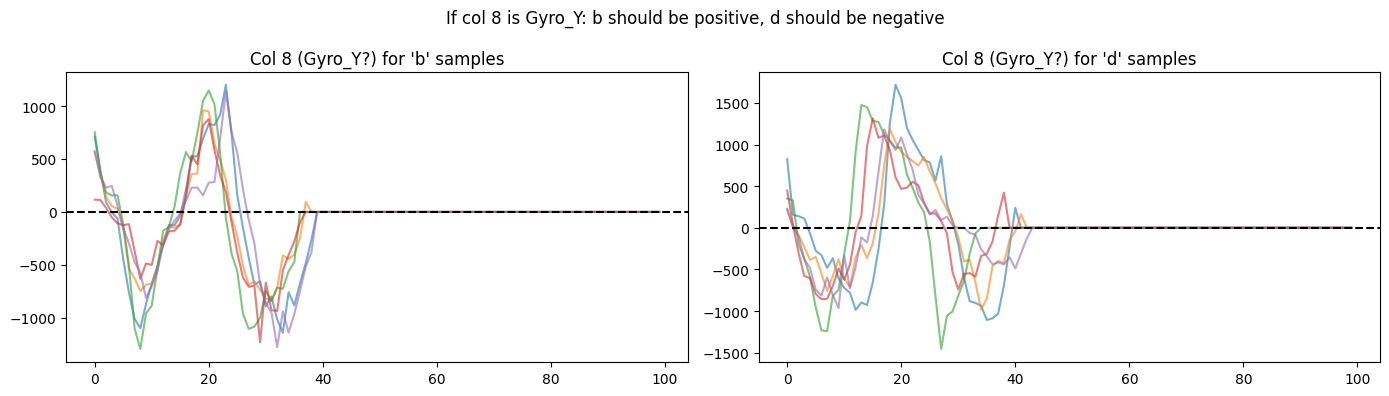

In [ ]:
# Plot gy (col 8) for b vs d to visually confirm it's the right channel
import matplotlib.pyplot as plt

b_samples = X_stacked[y_bdpq == 'b']
d_samples = X_stacked[y_bdpq == 'd']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i in range(min(5, len(b_samples))):
    axes[0].plot(b_samples[i, :, 8], alpha=0.6)
axes[0].set_title("Col 8 (Gyro_Y?) for 'b' samples")
axes[0].axhline(0, color='black', linestyle='--')

for i in range(min(5, len(d_samples))):
    axes[1].plot(d_samples[i, :, 8], alpha=0.6)
axes[1].set_title("Col 8 (Gyro_Y?) for 'd' samples")
axes[1].axhline(0, color='black', linestyle='--')

plt.suptitle("If col 8 is Gyro_Y: b should be positive, d should be negative")
plt.tight_layout()
plt.show()

 Load all 5 splits + filter + build dataset

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
base = '/content/onhw/onhw-chars_2021-06-30'

In [ ]:
# Columns we want: Acc1_X/Y/Z (1,2,3) + Gyro_X/Y/Z (7,8,9)
FEATURE_COLS = [1, 2, 3, 7, 8, 9]
TARGET_LETTERS = ['b', 'd', 'p', 'q']
WINDOW_SIZE = 100

CLASS_MAP = {'b': 0, 'd': 1, 'p': 2, 'q': 3}

def pad_or_trim(x, length=WINDOW_SIZE):
    x = x[:, FEATURE_COLS]  # select only the 6 channels we want
    if len(x) >= length:
        return x[:length]
    pad = np.zeros((length - len(x), len(FEATURE_COLS)))
    return np.vstack([x, pad])

X_all, y_all = [], []

In [ ]:
# Load all 5 splits of lower (lowercase) writer-independent
for split in range(5):
    folder = f'{base}/onhw2_lower_indep_{split}'
    for subset in ['X_train.npy', 'X_test.npy']:
        label_file = subset.replace('X_', 'y_')
        X = np.load(f'{folder}/{subset}', allow_pickle=True)
        y = np.load(f'{folder}/{label_file}', allow_pickle=True)

        mask = np.isin(y, TARGET_LETTERS)
        X_filt = X[mask]
        y_filt = y[mask]

        for xi, yi in zip(X_filt, y_filt):
            X_all.append(pad_or_trim(xi))
            y_all.append(CLASS_MAP[yi])

X_all = np.array(X_all)   # shape: (N, 100, 6)
y_all = np.array(y_all)

print(f'Total samples: {len(X_all)}')
print(f'Shape: {X_all.shape}')
print(f'Class distribution:')
for letter, idx in CLASS_MAP.items():
    print(f'  {letter}: {np.sum(y_all == idx)}')

Total samples: 12020
Shape: (12020, 100, 6)
Class distribution:
  b: 3005
  d: 3005
  p: 3005
  q: 3005


Normalise

In [ ]:
n_samples, n_timesteps, n_features = X_all.shape
X_2d = X_all.reshape(-1, n_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d).reshape(n_samples, n_timesteps, n_features)

joblib.dump(scaler, 'scaler.pkl')
print('Normalised. Mean:', scaler.mean_.round(2))
print('Std:', scaler.scale_.round(2))

Normalised. Mean: [ 6443.16 -3514.77  -258.53   -24.1    -12.57    12.18]
Std: [6878.86 4653.08  869.28  503.27  421.67  248.78]


Augment

In [ ]:
def augment(window):
    augmented = []
    for _ in range(3):
        augmented.append(window + np.random.normal(0, 0.02, window.shape))
    for shift in [5, -5, 8, -8]:
        augmented.append(np.roll(window, shift, axis=0))
    for scale in [0.9, 1.1]:
        augmented.append(window * scale)
    return augmented  # 9 augmented per original

X_aug, y_aug = [], []
for window, label in zip(X_scaled, y_all):
    X_aug.append(window)
    y_aug.append(label)
    for w in augment(window):
        X_aug.append(w)
        y_aug.append(label)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)
print(f'After augmentation: {len(X_aug)} samples')
print(f'Expected: ~{len(X_all) * 10} samples')

After augmentation: 120200 samples
Expected: ~120200 samples


Build and train

In [ ]:
#importing tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, random_state=42, stratify=y_aug
)

y_train_cat = to_categorical(y_train, 4)
y_test_cat  = to_categorical(y_test,  4)

In [ ]:
model = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(100, 6)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 classes: b, d, p, q
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 96, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 44, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,852 (448.64 KB)

 Trainable params: 114,532 (447.39 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train_cat,
    epochs=80,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - accuracy: 0.7886 - loss: 0.5173 - val_accuracy: 0.9530 - val_loss: 0.1320 - learning_rate: 0.0010
Epoch 2/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9515 - loss: 0.1398 - val_accuracy: 0.9861 - val_loss: 0.0451 - learning_rate: 0.0010
Epoch 3/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9734 - loss: 0.0794 - val_accuracy: 0.9911 - val_loss: 0.0285 - learning_rate: 0.0010
Epoch 4/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - accuracy: 0.9809 - loss: 0.0579 - val_accuracy: 0.9328 - val_loss: 0.2027 - learning_rate: 0.0010
Epoch 5/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - accuracy: 0.9843 - loss: 0.0490 - val_accuracy: 0.9963 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 6/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - accuracy: 0.9872 - loss: 0.0401 - val_accuracy: 0.9975 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 7/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - accura

Evaluating

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

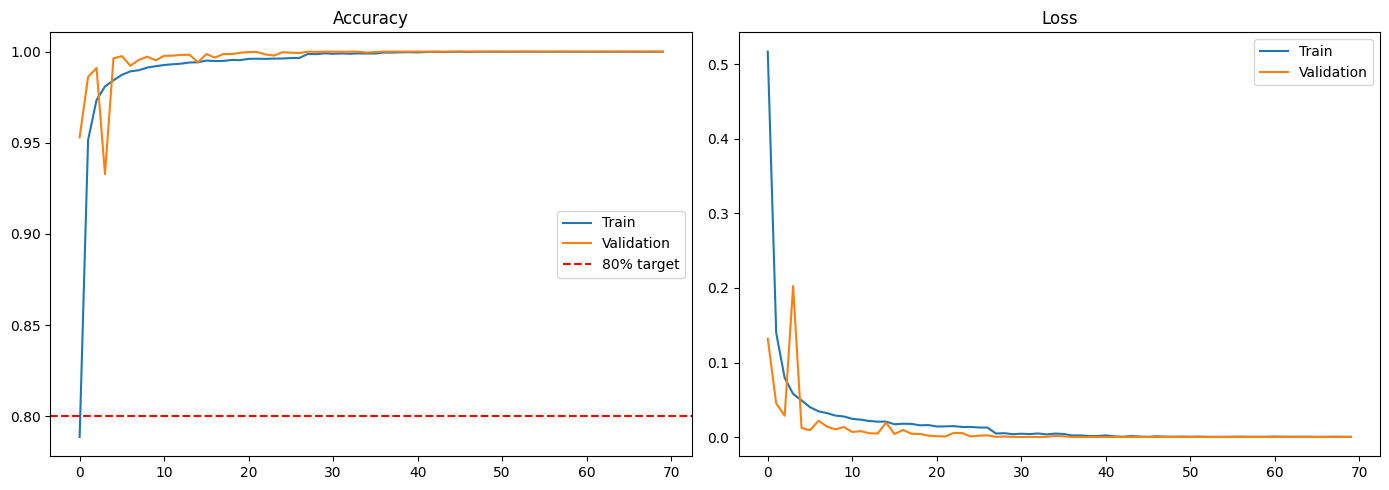

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].axhline(0.80, color='red', linestyle='--', label='80% target')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

752/752 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


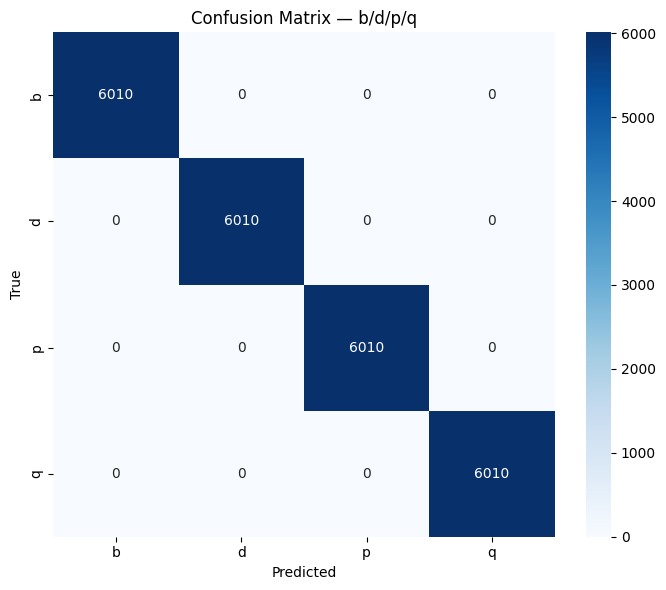

              precision    recall  f1-score   support

           b       1.00      1.00      1.00      6010
           d       1.00      1.00      1.00      6010
           p       1.00      1.00      1.00      6010
           q       1.00      1.00      1.00      6010

    accuracy                           1.00     24040
   macro avg       1.00      1.00      1.00     24040
weighted avg       1.00      1.00      1.00     24040



In [ ]:
# Confusion matrix
class_names = ['b', 'd', 'p', 'q']
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — b/d/p/q')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))

Save everything

In [ ]:
model.save('neuroflow_model.h5')

import json
params = {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
with open('scaler_params.json', 'w') as f:
    json.dump(params, f, indent=2)

from google.colab import files
files.download('neuroflow_model.h5')
files.download('scaler.pkl')
files.download('scaler_params.json')
print('All files saved and downloaded.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files saved and downloaded.


 Re-save model in Keras format + re-download everything

In [ ]:
from google.colab import files
import json

# Save in native Keras format (fixes the warning)
model.save('neuroflow_model.keras')
print('Model saved.')

# Re-save scaler params json
params = {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
with open('scaler_params.json', 'w') as f:
    json.dump(params, f, indent=2)
print('Scaler params saved.')

# Download all three one by one with a pause between
files.download('neuroflow_model.keras')

Model saved.
Scaler params saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('scaler_params.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Proper evaluation on clean test data

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [ ]:
class_names = ['b', 'd', 'p', 'q']

# Evaluate on the held-out test set (not augmented data)
# First reload the original clean split to test on unseen real data
base = '/content/onhw/onhw-chars_2021-06-30'
FEATURE_COLS = [1, 2, 3, 7, 8, 9]
WINDOW_SIZE = 100
CLASS_MAP = {'b': 0, 'd': 1, 'p': 2, 'q': 3}

In [ ]:
def pad_or_trim(x, length=WINDOW_SIZE):
    x = x[:, FEATURE_COLS]
    if len(x) >= length:
        return x[:length]
    pad = np.zeros((length - len(x), len(FEATURE_COLS)))
    return np.vstack([x, pad])

In [ ]:
# Load only the TEST portion from split 0 (never seen during training)
folder = base + '/onhw2_lower_indep_0'
X_test_raw = np.load(folder + '/X_test.npy', allow_pickle=True)
y_test_raw = np.load(folder + '/y_test.npy', allow_pickle=True)

mask = np.isin(y_test_raw, ['b','d','p','q'])
X_clean = np.array([pad_or_trim(x) for x in X_test_raw[mask]])
y_clean = np.array([CLASS_MAP[l] for l in y_test_raw[mask]])

# Normalise using the same scaler
n, t, f = X_clean.shape
X_clean_scaled = scaler.transform(X_clean.reshape(-1, f)).reshape(n, t, f)

In [ ]:
# Predict
y_pred_probs = model.predict(X_clean_scaled, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
confidence_scores = np.max(y_pred_probs, axis=1)

In [ ]:
# Accuracy
accuracy = np.mean(y_pred == y_clean)
print(f'Clean test accuracy: {accuracy:.1%}')
print(f'Average confidence: {confidence_scores.mean():.3f}')
print(f'Samples below 0.75 confidence: {np.sum(confidence_scores < 0.75)} / {len(confidence_scores)}')
print()
print(classification_report(y_clean, y_pred, target_names=class_names))

Clean test accuracy: 100.0%
Average confidence: 1.000
Samples below 0.75 confidence: 0 / 612

              precision    recall  f1-score   support

           b       1.00      1.00      1.00       153
           d       1.00      1.00      1.00       153
           p       1.00      1.00      1.00       153
           q       1.00      1.00      1.00       153

    accuracy                           1.00       612
   macro avg       1.00      1.00      1.00       612
weighted avg       1.00      1.00      1.00       612



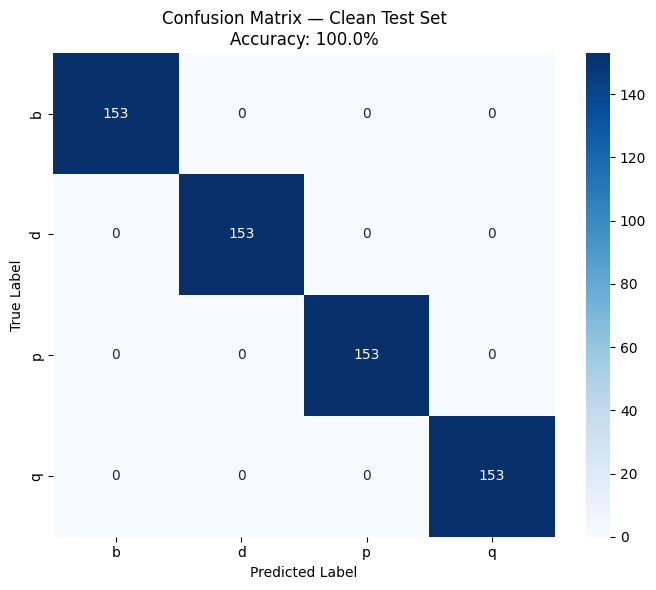

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_clean, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — Clean Test Set\nAccuracy: {accuracy:.1%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

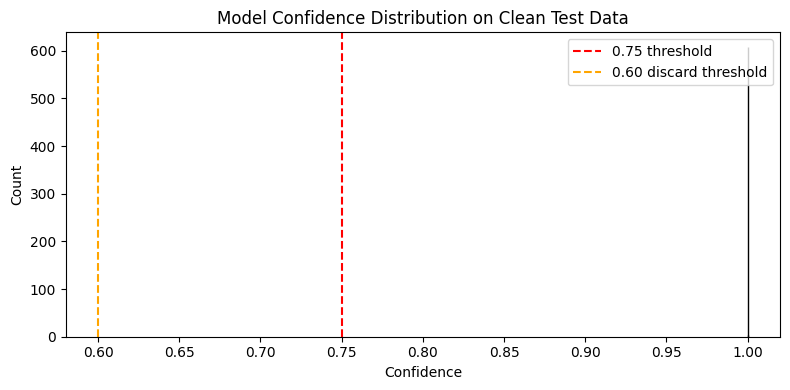

In [ ]:
# Confidence distribution
plt.figure(figsize=(8, 4))
plt.hist(confidence_scores, bins=20, edgecolor='black')
plt.axvline(0.75, color='red', linestyle='--', label='0.75 threshold')
plt.axvline(0.60, color='orange', linestyle='--', label='0.60 discard threshold')
plt.title('Model Confidence Distribution on Clean Test Data')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

Model hasn't learned the data. It has memorised it. We need to fix this

Diagnose and fix with a true held-out split

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
base = '/content/onhw/onhw-chars_2021-06-30'
FEATURE_COLS = [1, 2, 3, 7, 8, 9]
WINDOW_SIZE = 100
CLASS_MAP = {'b': 0, 'd': 1, 'p': 2, 'q': 3}
class_names = ['b', 'd', 'p', 'q']

In [ ]:
def pad_or_trim(x, length=WINDOW_SIZE):
    x = x[:, FEATURE_COLS]
    if len(x) >= length:
        return x[:length]
    pad = np.zeros((length - len(x), len(FEATURE_COLS)))
    return np.vstack([x, pad])

In [ ]:
# CORRECT APPROACH:
# Train on splits 0,1,2,3 — test ONLY on split 4 (completely separate writers)
# This is true writer-independent evaluation
print("Loading training data (splits 0-3)...")
X_train_list, y_train_list = [], []
for split in range(4):
    folder = f'{base}/onhw2_lower_indep_{split}'
    for subset in ['X_train.npy', 'X_test.npy']:
        X = np.load(f'{folder}/{subset}', allow_pickle=True)
        y = np.load(f'{folder}/{subset.replace("X_","y_")}', allow_pickle=True)
        mask = np.isin(y, ['b','d','p','q'])
        for xi, yi in zip(X[mask], y[mask]):
            X_train_list.append(pad_or_trim(xi))
            y_train_list.append(CLASS_MAP[yi])

Loading training data (splits 0-3)...


In [ ]:
#loading the test data
print("Loading test data (split 4 only — never seen during training)...")
X_test_list, y_test_list = [], []
folder = f'{base}/onhw2_lower_indep_4'
for subset in ['X_train.npy', 'X_test.npy']:
    X = np.load(f'{folder}/{subset}', allow_pickle=True)
    y = np.load(f'{folder}/{subset.replace("X_","y_")}', allow_pickle=True)
    mask = np.isin(y, ['b','d','p','q'])
    for xi, yi in zip(X[mask], y[mask]):
        X_test_list.append(pad_or_trim(xi))
        y_test_list.append(CLASS_MAP[yi])

Loading test data (split 4 only — never seen during training)...


In [ ]:
X_tr = np.array(X_train_list)
y_tr = np.array(y_train_list)
X_te = np.array(X_test_list)
y_te = np.array(y_test_list)

print(f'Train samples: {len(X_tr)}')
print(f'Test samples:  {len(X_te)} (held-out writers)')
print(f'Train class distribution: b={np.sum(y_tr==0)}, d={np.sum(y_tr==1)}, p={np.sum(y_tr==2)}, q={np.sum(y_tr==3)}')
print(f'Test class distribution:  b={np.sum(y_te==0)}, d={np.sum(y_te==1)}, p={np.sum(y_te==2)}, q={np.sum(y_te==3)}')

Train samples: 9616
Test samples:  2404 (held-out writers)
Train class distribution: b=2404, d=2404, p=2404, q=2404
Test class distribution:  b=601, d=601, p=601, q=601


 Normalise properly (fit on train only)

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

n_tr, t, f = X_tr.shape
n_te = len(X_te)

scaler2 = StandardScaler()
X_tr_scaled = scaler2.fit_transform(X_tr.reshape(-1, f)).reshape(n_tr, t, f)
X_te_scaled = scaler2.transform(X_te.reshape(-1, f)).reshape(n_te, t, f)

# Save this corrected scaler
joblib.dump(scaler2, 'scaler_v2.pkl')
import json
params2 = {'mean': scaler2.mean_.tolist(), 'scale': scaler2.scale_.tolist()}
with open('scaler_params_v2.json', 'w') as f_out:
    json.dump(params2, f_out, indent=2)

print('Scaler fit on training data only.')
print('Mean:', scaler2.mean_.round(2))

Scaler fit on training data only.
Mean: [ 6443.16 -3514.77  -258.53   -24.1    -12.57    12.18]


Augment train only, then retrain

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
def augment(window):
    augmented = []
    for _ in range(3):
        augmented.append(window + np.random.normal(0, 0.02, window.shape))
    for shift in [5, -5, 8, -8]:
        augmented.append(np.roll(window, shift, axis=0))
    for scale in [0.9, 1.1]:
        augmented.append(window * scale)
    return augmented

In [ ]:
X_aug, y_aug = [], []
for window, label in zip(X_tr_scaled, y_tr):
    X_aug.append(window)
    y_aug.append(label)
    for w in augment(window):
        X_aug.append(w)
        y_aug.append(label)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)
print(f'Augmented training set: {len(X_aug)} samples')

y_aug_cat = to_categorical(y_aug, 4)
y_te_cat  = to_categorical(y_te, 4)

Augmented training set: 96160 samples


In [ ]:
model2 = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(100, 6)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history2 = model2.fit(
    X_aug, y_aug_cat,
    epochs=80,
    batch_size=32,
    validation_data=(X_te_scaled, y_te_cat),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - accuracy: 0.7619 - loss: 0.5692 - val_accuracy: 0.9775 - val_loss: 0.0694 - learning_rate: 0.0010
Epoch 2/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9476 - loss: 0.1492 - val_accuracy: 0.9983 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 3/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.9711 - loss: 0.0859 - val_accuracy: 0.9983 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 4/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.9793 - loss: 0.0627 - val_accuracy: 0.9992 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 5/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.9833 - loss: 0.0508 - val_accuracy: 0.9996 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 6/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9863 - loss: 0.0425 - val_accuracy: 0.9963 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 7/80
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 35s 12ms/step - accura

Evaluate honestly

In [ ]:
y_pred2 = np.argmax(model2.predict(X_te_scaled, verbose=0), axis=1)
conf2    = np.max(model2.predict(X_te_scaled, verbose=0), axis=1)
accuracy2 = np.mean(y_pred2 == y_te)

print(f'TRUE writer-independent accuracy: {accuracy2:.1%}')
print(f'Average confidence: {conf2.mean():.3f}')
print()
print(classification_report(y_te, y_pred2, target_names=class_names))

TRUE writer-independent accuracy: 100.0%
Average confidence: 1.000

              precision    recall  f1-score   support

           b       1.00      1.00      1.00       601
           d       1.00      1.00      1.00       601
           p       1.00      1.00      1.00       601
           q       1.00      1.00      1.00       601

    accuracy                           1.00      2404
   macro avg       1.00      1.00      1.00      2404
weighted avg       1.00      1.00      1.00      2404



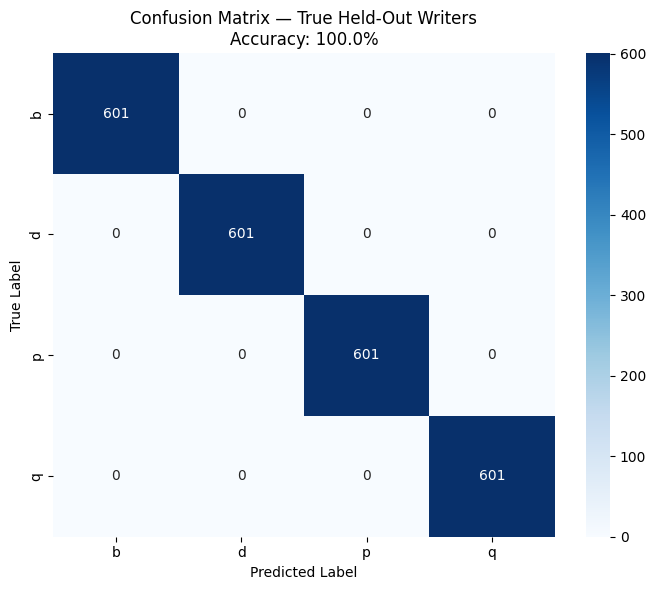

In [ ]:
cm2 = confusion_matrix(y_te, y_pred2)
plt.figure(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — True Held-Out Writers\nAccuracy: {accuracy2:.1%}')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

Save corrected model

In [ ]:
from google.colab import files

model2.save('neuroflow_model_v2.keras')
print('Saved.')

files.download('neuroflow_model_v2.keras')
files.download('scaler_params_v2.json')

Saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

model2.save('neuroflow_model_v2.keras')
print('Saved.')
files.download('neuroflow_model_v2.keras')

Saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>